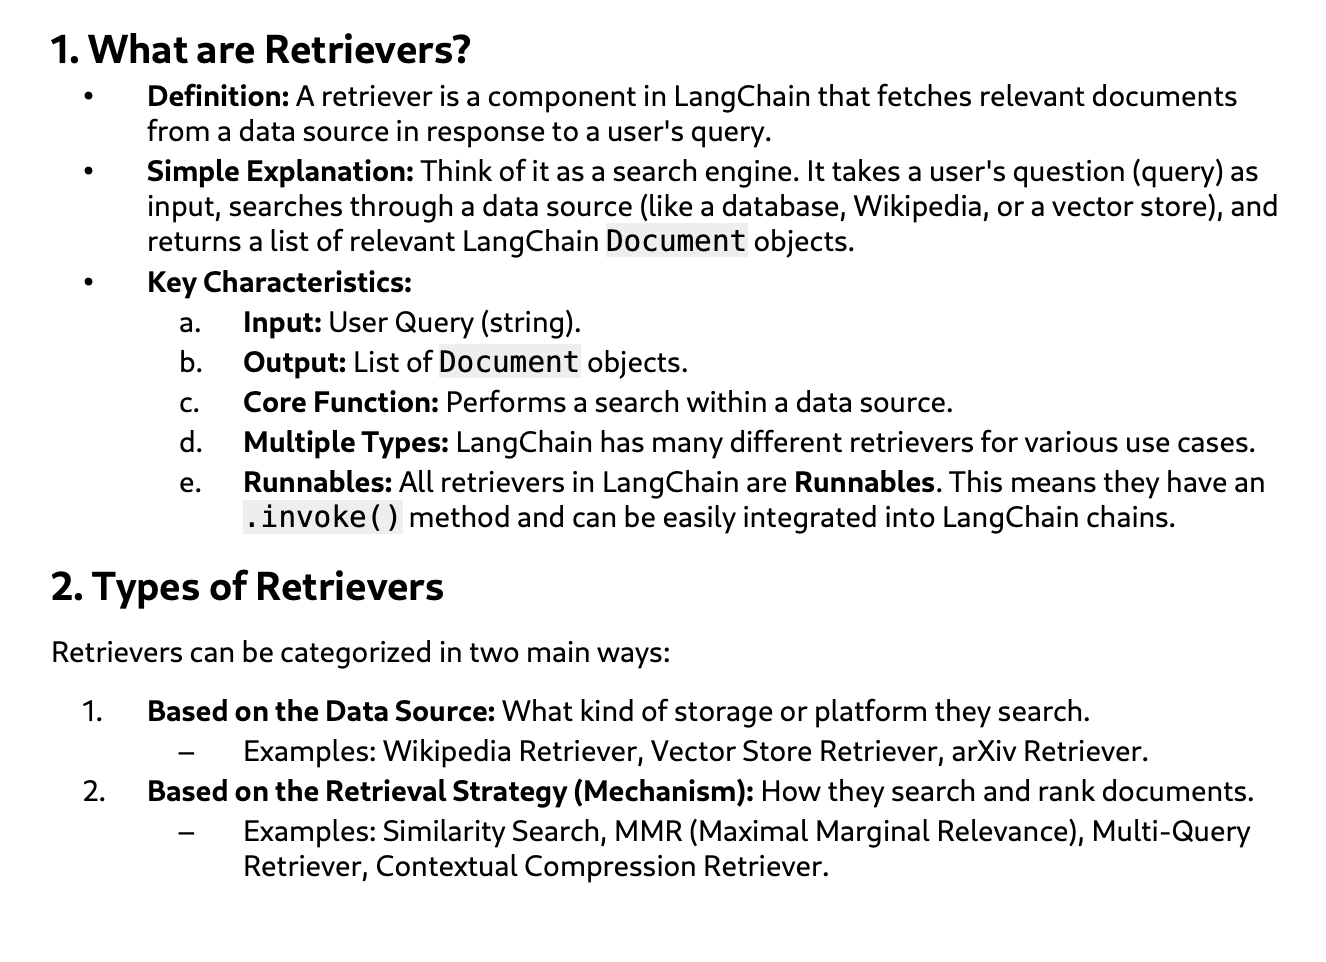

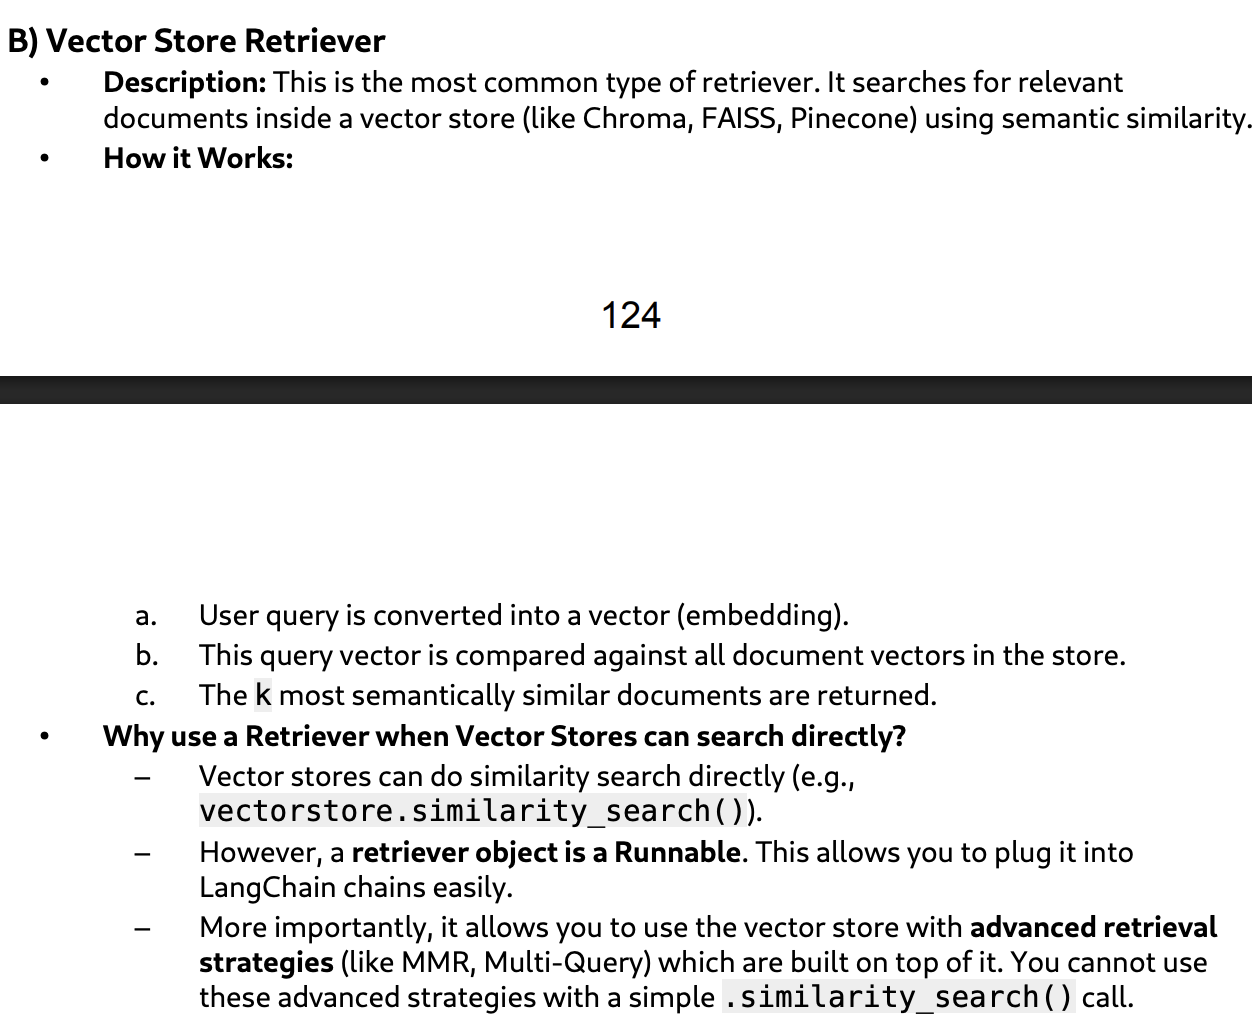

In [2]:
from langchain_chroma import Chroma
from langchain_core.documents import Document

#### Create sample documents

In [5]:

documents = [
 Document(page_content="LangChain is a framework for building LLM applications."),
 Document(page_content="Chroma is a vector store used in LangChain."),
 Document(page_content="Embeddings convert text into numerical vectors."),
]

#### 2.Create a vector store(Chroma in this case)

In [6]:
from langchain_huggingface.embeddings import HuggingFaceEndpointEmbeddings
from dotenv import load_dotenv
import os

load_dotenv()
api_key = os.getenv("Hugging_face_api_token")
hf_embeddings_api = HuggingFaceEndpointEmbeddings(
    model="sentence-transformers/all-MiniLM-L6-v2",  # lightweight
    # model="Qwen/Qwen3-Embedding-8B",
    # task="feature-extraction",# heavyweight but uses a lot of quota token
    huggingfacehub_api_token=api_key,
)

In [9]:
vectorstore=Chroma.from_documents(
    documents=documents,
    embedding=hf_embeddings_api,
    persist_directory="./2VectorDatabaseChroma",
    collection_name="table1"
)

# 3.Create a retriever from the vector store

In [10]:
retriever=vectorstore.as_retriever(search_kwargs={
    "k":2
})

### 4.Use the retriever

In [11]:
query="What is Chroma used for?"
results=retriever.invoke(query)

### 5.Print results


In [13]:
for i,doc in enumerate(results):
    print(f"---Result {i+1}---")
    print(type(doc))
    print(doc.page_content)
    print("-"*20)

---Result 1---
<class 'langchain_core.documents.base.Document'>
Chroma is a vector store used in LangChain.
--------------------
---Result 2---
<class 'langchain_core.documents.base.Document'>
LangChain is a framework for building LLM applications.
--------------------
